<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Neural_Networks_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks:

## Neural Networks Basics:

input layer -> activation layer -> output layer

* input lyaer : Takes input
* Activation layer : multiple layers with multiple numbers of neurons
* output layer : shows output

Every neuron of a layer has access to every other neuron's output from previous layer.

Models figure out which inputs are needed and which to ignore. We don't decide manually which neurons to use or which ones to ignore.

> Activataion layer is also known as hidden layer
because we can't manually change inputs of this layer for correct inputs and outputs.

Each neuron does logistic regression and the pass the outputs to next layers neurons.

> Forward Propagation: calculation happens on the left side and then passed to the right.






### Choosing Activation func:

Output layer:

a. binary classification : sigmoid [uses probability]

b. Regression (can get +ve/-ve) : Linear [predicts any number]

c. Regression (only +ve) : ReLU [Predicts >=0]

Sigmoid is flat on both side : Slower Grad Descent

ReLU is flat on one side only : Faster Grad Descent



If u use Linear func every where on the model : The whole model works like a linear regression func.

if all hidden layers using linear & output layer uses logistic func : Sigmoid Func

Rule of thumb : ReLU activation for hidden layers!

### Setting things up:

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='training_loss')
    plt.plot(history.history['val_loss'], label='validation_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary crossentropy')
    plt.legend()
    plt.show()

def plot_accuracy(history):
    plt.figure(figsize=(8,5))

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')

    plt.legend()
    plt.show()

def plot_history(history):
    plot_loss(history)
    plot_accuracy(history)

### Creating DataSet

In [35]:
X = np.array([
    [1, 30],
    [2, 35],
    [3, 40],
    [4, 50],
    [5, 55],
    [6, 60],
    [7, 70],
    [8, 75],
    [9, 85],
    [10, 95]
], dtype=np.float32)
# Labels:
# 0 = fail
# 1 = pass
y = np.array([
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1
], dtype=np.float32)

In [36]:
X.shape

(10, 2)

10 training examples with 2 features on each example

In [37]:
y.shape

(10,)

10 answers for 10 examples

### Normalizing Data:

features are now:

Study hours: 1-10

attendace: 30-95

The difference is huge, so we will scale them to a reasonable level

In [38]:
# divide by max val normalization
X=X/np.array([10, 100]) # dividing each col with their max val
X

array([[0.1 , 0.3 ],
       [0.2 , 0.35],
       [0.3 , 0.4 ],
       [0.4 , 0.5 ],
       [0.5 , 0.55],
       [0.6 , 0.6 ],
       [0.7 , 0.7 ],
       [0.8 , 0.75],
       [0.9 , 0.85],
       [1.  , 0.95]])

Now values are from 0 to 1!

### Build Neural Network:

In [39]:
model=Sequential([
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="sigmoid"), # last layer must be sigmoid
    ]
)

### Compile Model:

In [40]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

### Fitting Model:

In [41]:
history=model.fit(
    X,y, epochs=100,
    validation_split=0.2,
    verbose=False
)

### Saving History to Plot

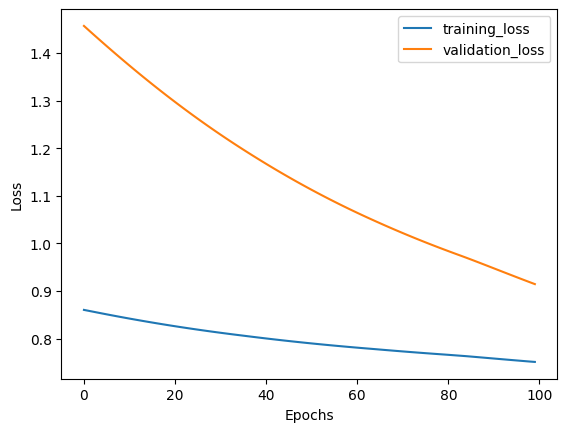

In [42]:
plt.plot(history.history["loss"], label='training_loss')
plt.plot(history.history["val_loss"], label='validation_loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Predicting new data:

In [43]:
new_student = np.array([7, 88])
# normalize same wayy
new_student = new_student / np.array([10, 100])
new_student_batched = new_student.reshape(1, -1)
prediction = model.predict(new_student_batched)
print(prediction)
if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.43220195]]
Fail


### Using a Denser Model:

In [44]:
model=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history=model.fit(X, y, epochs=100, validation_split=0.2, verbose=False)

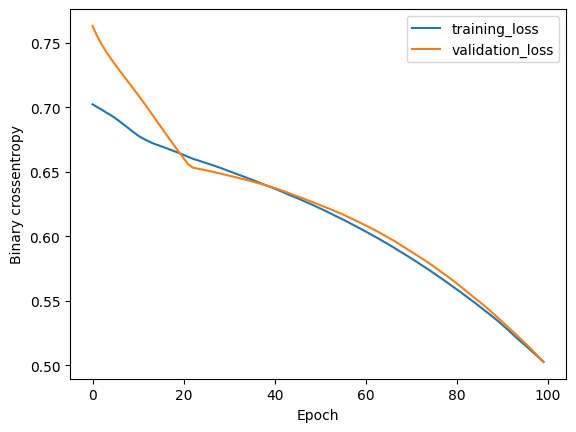

In [45]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='training_loss')
    plt.plot(history.history['val_loss'], label='validation_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary crossentropy')
    plt.legend()
    plt.show()
plot_loss(history)

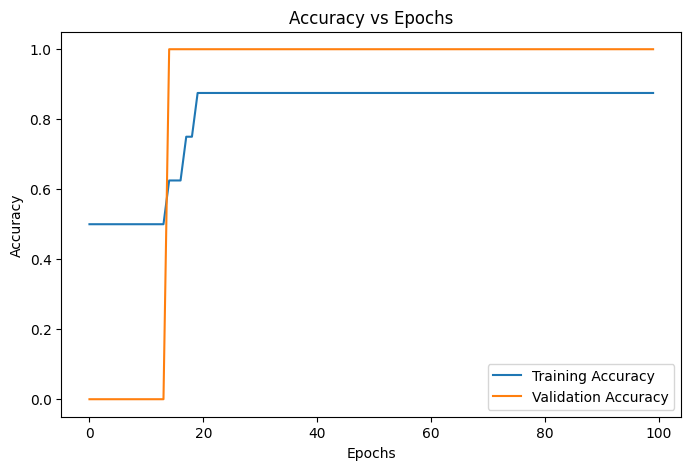

In [46]:
def plot_accuracy(history):
    plt.figure(figsize=(8,5))

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')

    plt.legend()
    plt.show()

plot_accuracy(history)

Training Loss came to almost 0, but the validation loss didn't decrease much. It's because our model is too dense.

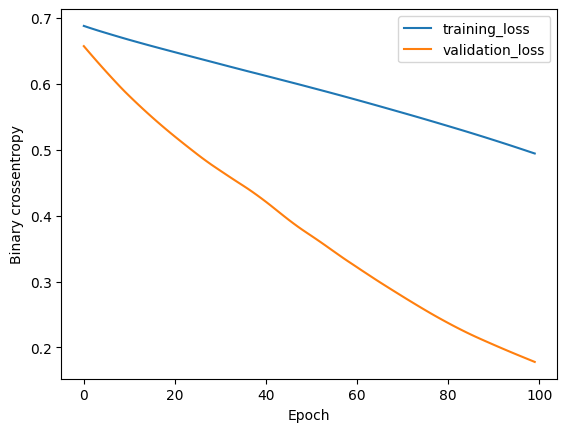

In [47]:
model=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)
plot_loss(history)

Training loss decreaseed from 0.7 to 0.55, but validation loss got pretty lower, almost 0, because model adapated to the dataset pretty well.

10 data with 20/50 neurons are not working, we need a bigger dataset to observe them properly.

### Using Larger Dataset

In [48]:
X = np.random.rand(200,2)
X[1]
# 0: study_hours + 1: attendance

# if study_hours + attendance is high -> pass
y = ((X[:, 0] * 50 + X[:, 1] * 50) > 50).astype(np.float32)
X.shape

(200, 2)

Simple Model:

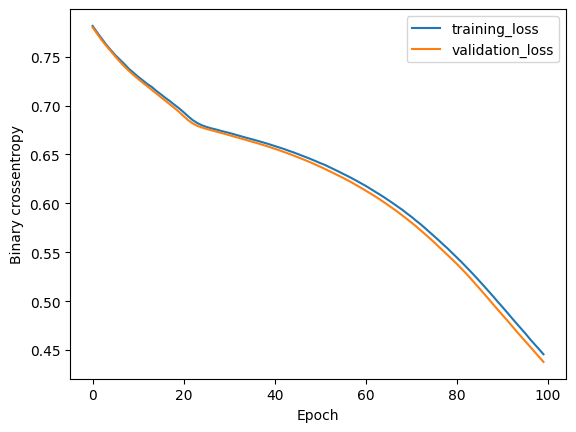

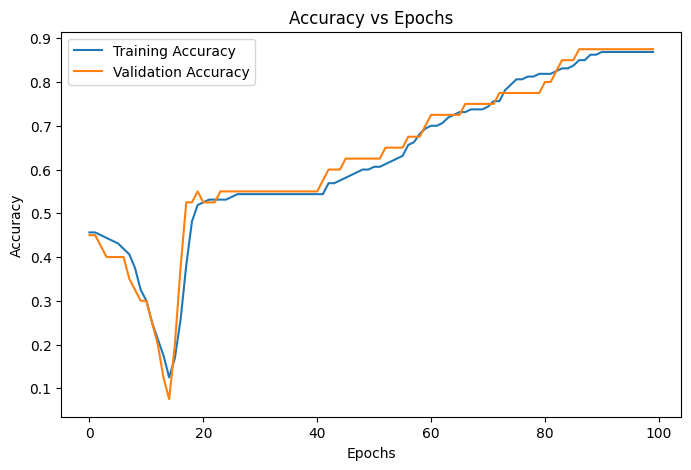

In [52]:
model1=Sequential([
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model1.fit(X, y, epochs=100, validation_split=0.2, verbose=False)
plot_loss(history)
plot_accuracy(history)

model is doing much bettter with larger dataset, both losses are decreasing but it's not done yet!

Mid density model:

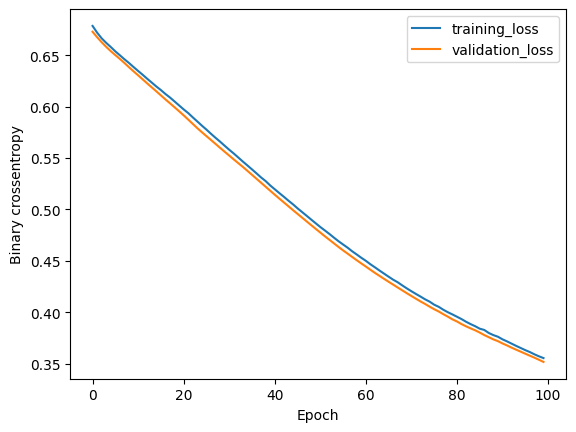

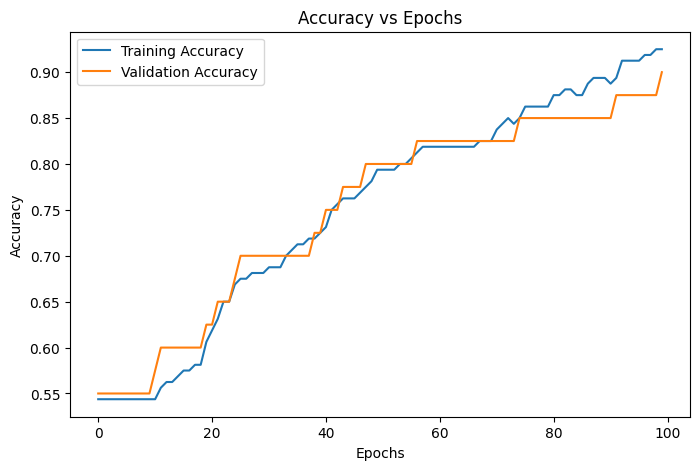

In [53]:
model1=Sequential([
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model1.fit(X, y, epochs=100, validation_split=0.2, verbose=False)
plot_loss(history)
plot_accuracy(history)

Losses came down to almost 0!

Highly Densed Model:


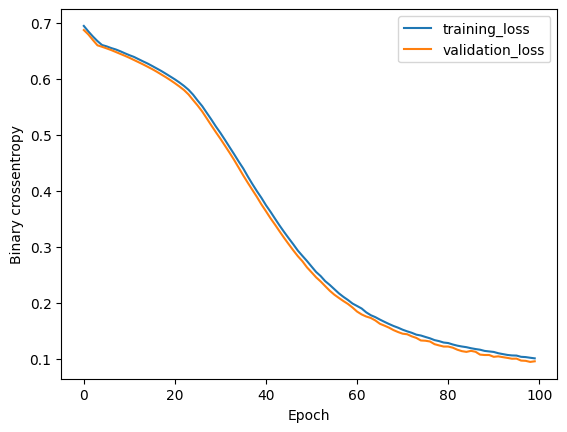

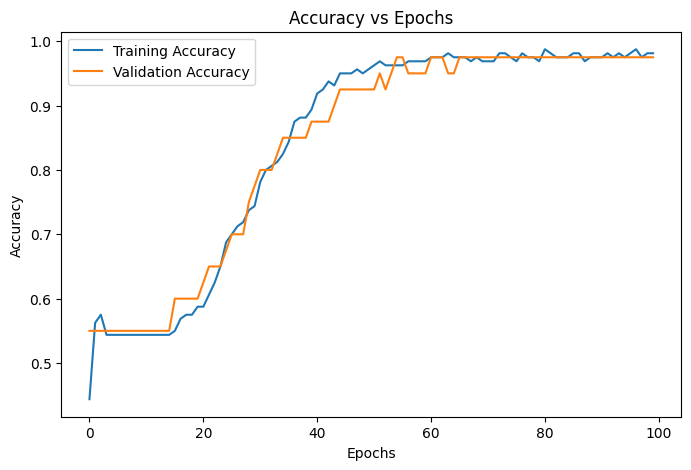

In [54]:
model1=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model1.fit(X, y, epochs=100, validation_split=0.2, verbose=False)
plot_loss(history)
plot_accuracy(history)

Why Did Both Curves Start at ~0.7?

Binary crossentropy near:

0.693

is mathematically special.

Because:

sigmoid outputs near 0.5 initially model starts uncertain/random

And:

−log(0.5)≈0.693

So:

~0.69 loss

basically means:

“the network is initially guessing randomly.”

Data Quality Always Wins:

A complex neural network means absolutely nothing if you feed it garbage or a microscopic dataset. Your first model failed because 10 samples couldn't map a real mathematical boundary. Your second model succeeded because 200 balanced samples gave it enough geometry to calculate clean gradients.


### Loss vs Accuracy



Accuracy

Measures how many predictions are correct.
Easy to understand.
Used for evaluating the model.

Loss

Measures how wrong the predictions are.
Considers the confidence of predictions.
Used by the optimizer to update weights during training.

Key Point

Two models can have the same accuracy but different loss.
During training, loss decreases first because the model becomes more confident, while accuracy may stay the same.

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Create dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Build Neural Network
model = Sequential([
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=False,
    validation_data=(X_test, y_test)
)


```text
make_classification()

Creates a synthetic dataset for binary classification.

Parameters:

n_samples      -> Number of training examples (rows)
n_features     -> Total number of features (columns)
n_informative  -> Number of useful features for prediction
random_state   -> Fixes randomness for reproducible results
```


## Multiclass Classification:


We're going to use Fashion MNIST Dataset and we will classify shirts, shoes, bags, trousers, etc

### 1. Loading Dataset:

In [61]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train[5]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172,
        132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242,
        255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150,
        162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162,
        155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187,
        184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210,
        212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  88, 221, 215, 217, 219, 211, 185, 150, 118,
        107,  99,  88,  83,  90, 135, 212, 203, 207, 219, 169,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  27, 118, 162,  40,   0,   0,   0,  10,
         19,  28,  39,  47,  36,   0,   0, 203, 230, 220, 203,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 138, 136,  71,  69,  54, 216, 217, 203, 184,
        168, 163, 162, 163, 178, 221, 186,  38,  26,   7,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  67, 134, 154, 224, 129,  66,  81, 117, 129,
        128, 132, 137, 131, 129,  86,  73, 157, 151, 134, 216,  18,   0,
          0,   0],
       [  0,   0,   0,   0, 203, 198, 172, 183, 206, 255, 255, 250, 243,
        240, 239, 235, 238, 244, 255, 238, 184, 160,  86,  98,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 122, 188, 224, 151, 105, 127,  97, 100, 105,
        114, 117, 117, 113, 103,  98, 111, 142, 254, 191, 255,  49,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 179, 200,  95, 154, 198, 197, 200, 200,
        198, 197, 198, 199, 202, 200, 176,  86, 206, 157, 162,  10,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 201, 229,  71, 144, 194, 181, 183, 179,
        182, 180, 179, 180, 190, 185, 197,  76, 219, 185, 201,  34,   0,
          0,   0],
       [  0,   0,   0,   0, 199, 193, 226,  58, 154, 192, 184, 187, 184,
        186, 184, 185, 183, 192, 191, 200,  56, 219, 203, 207,  60,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 194, 224,  41, 163, 190, 186, 186, 184,
        185, 183, 185, 178, 190, 194, 202,  33, 211, 200, 206,  73,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 197, 222,  17, 172, 190, 186, 187, 182,
        186, 185, 187, 180, 187, 193, 202,  26, 212, 202, 203,  76,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 177, 189, 184, 185, 178,
        184, 183, 184, 180, 183, 189, 203,  35, 196, 203, 203,  84,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 185, 187, 185, 187, 180,
        184, 182, 183, 178, 182, 183, 205,  44, 159, 207, 201,  85,   0,
          0,   0],
       [  0,   0,   0,   0, 187, 198, 225,   0, 194, 188, 184, 185, 180,
        183, 183, 184, 181, 181, 177, 206,  46, 129, 211, 200,  88,   0,
          0,   0],
       [  0,   0,   0,   6, 186, 200, 211,   0, 199, 189, 184, 184, 185,
        182, 183, 184, 185, 182, 175, 205,  50,  97, 216, 197,  93,   0,
          0,   0],
       [  0,   0,   0,   5, 185, 204, 184,   0, 202, 188, 182, 182, 183,
        183, 184, 182, 180, 182, 174, 202,  63,  59, 220, 196,  94,   0,
          0,   0],
       [  0,   0,   0,   5, 184, 206, 157,   0, 204, 187, 187, 189, 192,
        190, 190, 191, 190, 187, 183, 202,  78,  35, 222, 197,  95,   0,
          0,   0],
       [  0,   0,   0,   5, 183, 208, 127,   0, 197, 166, 153, 149, 149,
        146, 148, 149, 150, 151, 158, 191,  90,   8, 223, 195,  99,   0,
          0,   0],
       [  0,   0,   0,   6, 184, 208, 11

In [62]:
print(X_train.shape)
print()
print(y_train.shape)

(60000, 28, 28)

(60000,)


60000 examples, each has 28 X 28 pixels.


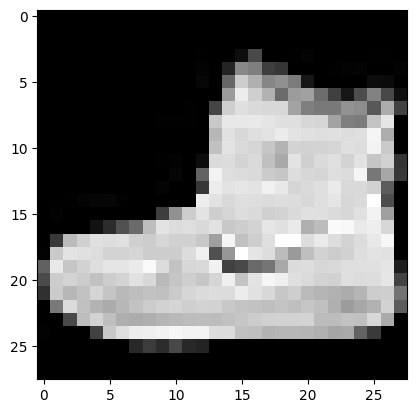

9


In [63]:
plt.imshow(X_train[0], cmap='gray')
plt.show()
print(y_train[0])


In [64]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

Each image:

is just a matrix of numbers pixel intensities:

0 → black

255 → white

### 2. Normalizing Data

Now pixels are 0-255, we will make them from 0 to 1



In [66]:
X_train=X_train/255.0
X_test=X_test/255.0

### 3. Building Model

In [67]:
model=Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    Dense(124, activation='relu'),
    Dense(10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Flatten Layer
Images are: 28 × 28

But Dense layers expect:
1D vector

Flatten converts:
28×28 → 784

Output Layer : Dense(10, activation='softmax')

Why 10?

Because:
 10 clothing categories

Why Softmax?

Softmax outputs:
probabilities for ALL classes

Example output:

[0.01, 0.02, 0.90, 0.01, ...]

Meaning:

90% probability class 2 2% probability class 1 etc.

AND:

all probabilities sum to 1

### 4. Compile Model

In [68]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Why Sparse Categorical Crossentropy?
Your labels are:

0,1,2,3,4...

NOT:

[0,0,1,0,0]

So we use:

> sparse_categorical_crossentropy

TensorFlow internally handles encoding

### 5. Train

In [69]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=False
)

### 6. Evaluate

In [70]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8289 - loss: 0.4791
0.8288999795913696


In [71]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8289 - loss: 0.4791
0.8288999795913696


### 7. Make Predictions

In [76]:
predictions = model.predict(X_test)

np.set_printoptions(suppress=True, precision=12)
print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0.000000292162 0.000000000272 0.000000061987 0.000004107203
 0.000003950657 0.17882618     0.000005558163 0.37254372
 0.0051797726   0.44343624    ]


This shows the probability of something belonging to class 1 to 10.

Max Prob is class 10, 0.87 and 2nd most is 0.124. So, it's more likely belong to class 10.

### 8. Find Predicted Class

In [77]:
predicted_class = np.argmax(predictions[0])

print(predicted_class)
print(y_test[0])

9
9


argmax means:
index of largest value

If:
[0.1, 0.2, 0.7]

Then:
argmax = 2

because:
0.7 is largest

### 9. Show Image + Prediction

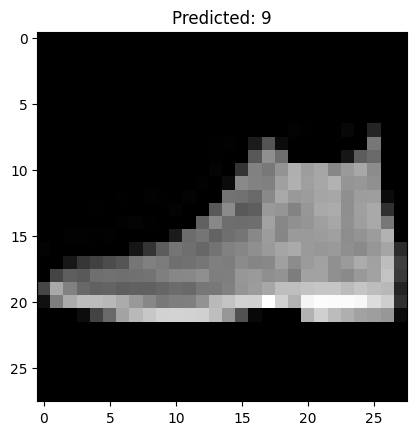

In [78]:
plt.imshow(X_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.show()

### 10. Confusion Matrix

In [79]:
from sklearn.metrics import confusion_matrix
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[765   7   5  94   3   2 105   0  19   0]
 [  3 929  15  44   4   0   3   0   2   0]
 [ 17   2 591   9 148   0 225   0   8   0]
 [ 37  10   0 834  21   0  91   0   7   0]
 [  0   2 176  50 597   0 166   0   9   0]
 [  0   0   0   1   0 888   1  67   7  36]
 [176   2 100  59 112   0 521   0  30   0]
 [  0   0   0   0   0  62   0 859   0  79]
 [  2   2   1   8   1   8  51   2 923   2]
 [  0   0   0   0   0  34   0  55   6 905]]


What Confusion Matrix Means
It shows:

where model gets confused

Example:

shirts mistaken as coats
sandals mistaken as sneakers

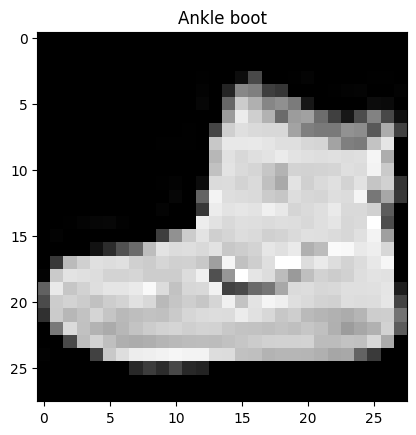

In [80]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.show()


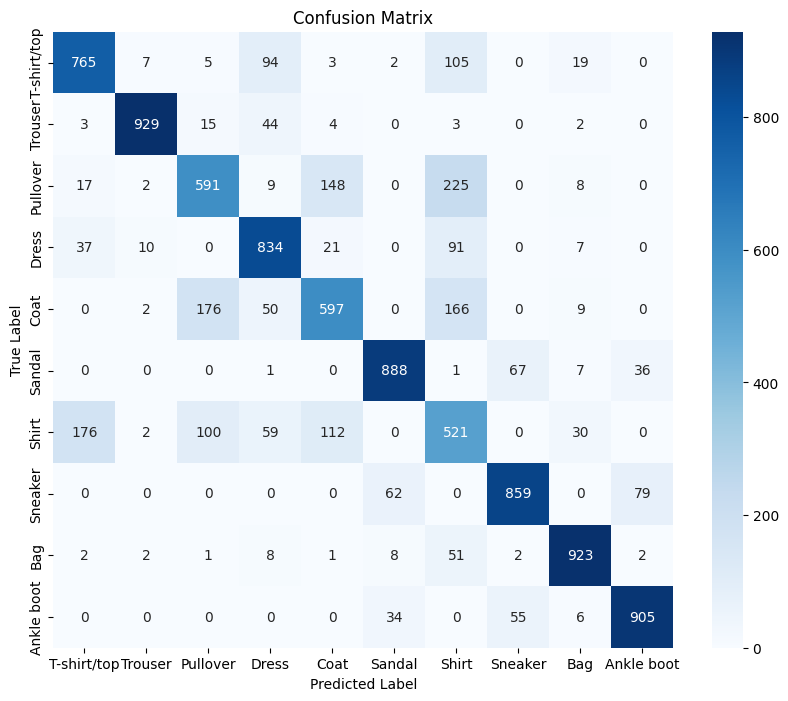

In [81]:
import seaborn as sns
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Overfitting vs Underfitting

### 1. Imports

In [82]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

### 2. Load Data

In [83]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

### 3. Normalization

In [84]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### 4. Small Dataset

In [85]:
X_trail_small=X_train[:1000]
y_trail_small=y_train[:1000]

### 5. Using a Small Model

In [86]:
tiny_model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(8, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 6. Compile

In [87]:
tiny_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 7. Train the model

In [88]:
tiny_history=tiny_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=10,
    validation_split=0.2,
    verbose=False
)

### 8. Plot Function

In [89]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    #loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    #accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

In [91]:
print(tiny_history.history)

{'accuracy': [0.16875000298023224, 0.23874999582767487, 0.33000001311302185, 0.4662500023841858, 0.5899999737739563, 0.6299999952316284, 0.6449999809265137, 0.6600000262260437, 0.6762499809265137, 0.6725000143051147], 'loss': [2.1748430728912354, 1.9516383409500122, 1.769288182258606, 1.5469266176223755, 1.3710448741912842, 1.2353307008743286, 1.1244254112243652, 1.0329277515411377, 0.9552835822105408, 0.8934597969055176], 'val_accuracy': [0.17000000178813934, 0.1850000023841858, 0.3799999952316284, 0.4699999988079071, 0.5450000166893005, 0.5849999785423279, 0.6000000238418579, 0.6000000238418579, 0.6349999904632568, 0.6100000143051147], 'val_loss': [2.1376895904541016, 1.9413954019546509, 1.7079403400421143, 1.5272514820098877, 1.3726211786270142, 1.2586456537246704, 1.1606621742248535, 1.0847736597061157, 1.017570972442627, 0.9609236717224121]}


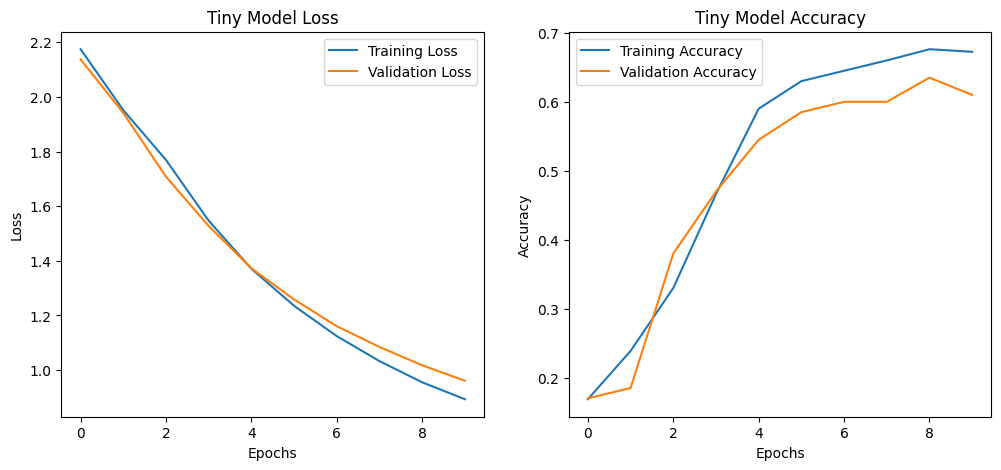

In [92]:
plot_history(tiny_history, "Tiny Model")

Loss decreased

Meaning:
predictions improved over time.

Accuracy increased
Meaning:
model learned meaningful patterns.

BUT:

```
Loss still ending near: 1.0 ->  is relatively high.
```

70% accuracy for Fashion MNIST is mediocre.

This suggests:

```UNDERFITTING```

Meaning:

model is too weak/simple.

Exactly what we expected from : Dense(8)

### Using a Mid Model

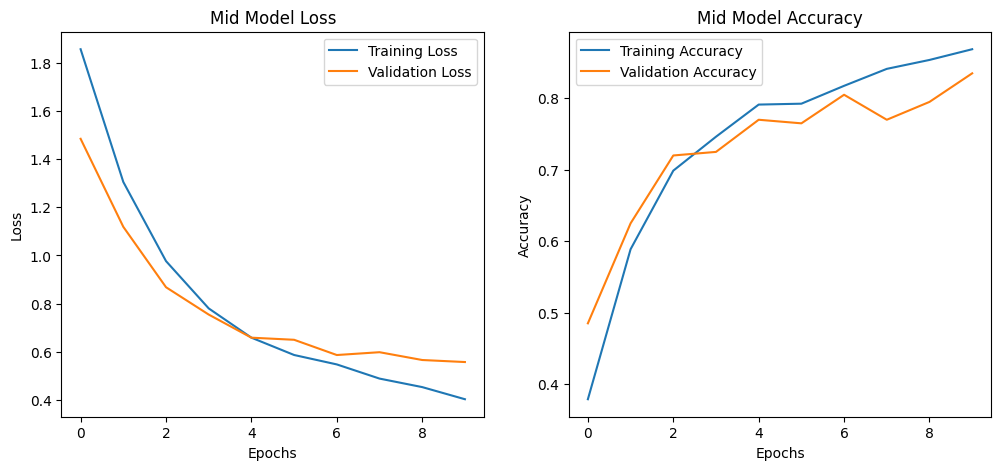

In [93]:
mid_model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=10,
    validation_split=0.2,
    verbose=False
)
plot_history(mid_history, "Mid Model")

Loss Came down for both

Training Set: 2 to 0.4

Validation Set: 1.65 to 0.6

Epoch is low, so it didn't get enough repetition to learn from.

Accuracy: Went upto 90% for Training Set and for Validation set it went upto 75%, not bad considering it didnt get enough repeatition.

**With more epoch**

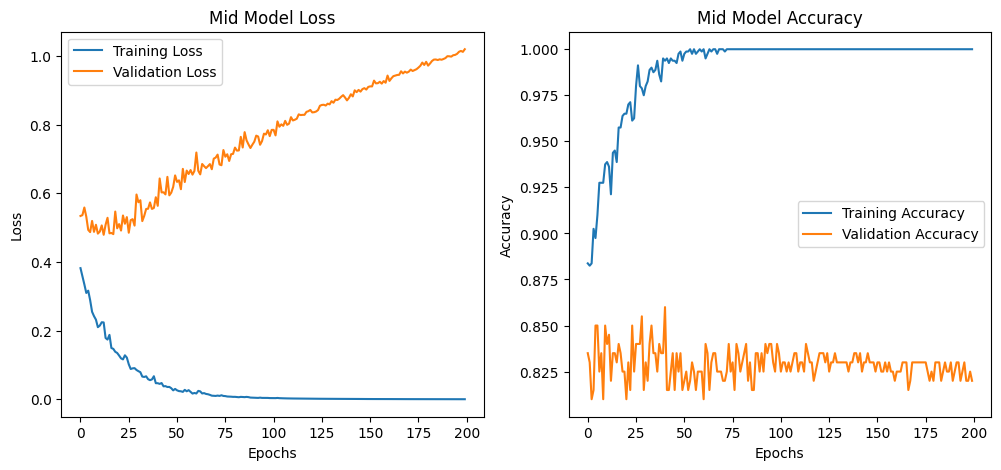

In [94]:
mid_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=200,
    validation_split=0.2,
    verbose=False
)
plot_history(mid_history, "Mid Model")

We overfitted here by increasing epoch to 200, not both loss and accuracy got stuck for validation set.

Need to use lower epoch

More Epoch -> more repitition -> better learning

but what is it learning?

with lower and specific epoch, it's learning patterns, and with more epoch, it's memorizing examples from trianing set

**Using mid level epoch, instead of hugeee**

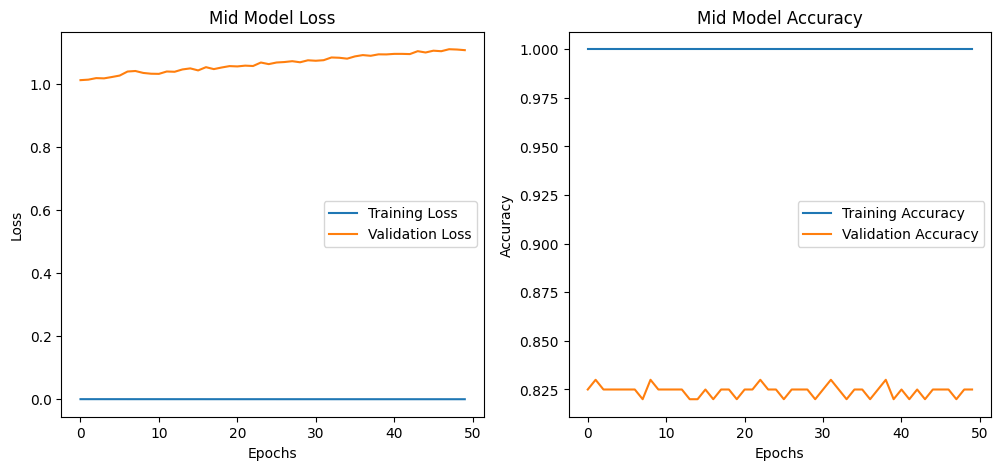

In [95]:
mid_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=50,
    validation_split=0.2,
    verbose=False
)
plot_history(mid_history,"Mid Model")


**Larger model with smaller dataset**

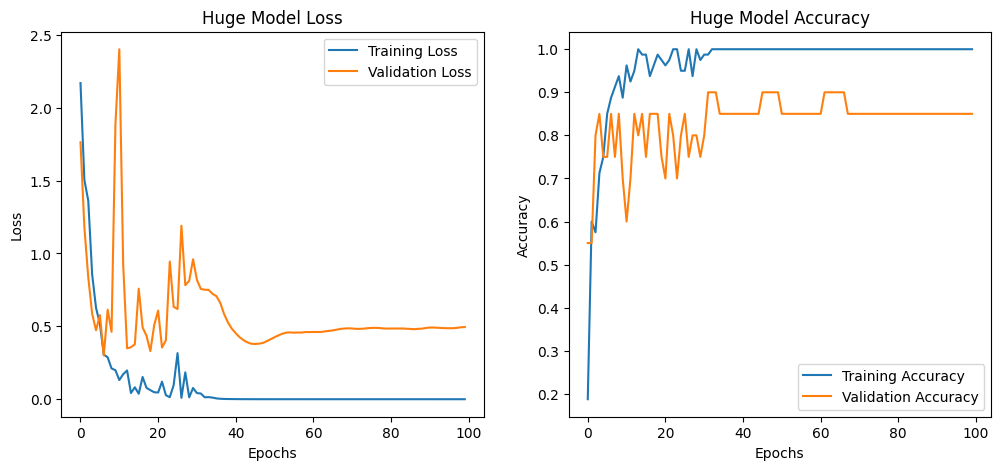

In [96]:
X_trail_small=X_train[:100]
y_trail_small=y_train[:100]
huge_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(1080, activation='relu'),
    Dense(720, activation='relu'),
    Dense(480, activation='relu'),
    Dense(360, activation='relu'),
    Dense(10, activation='softmax')
])
huge_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
huge_history=huge_Model.fit(
    X_trail_small,
    y_trail_small,
    epochs=100,
    validation_split=0.2,
    verbose=False
)
plot_history(huge_history, "Huge Model")

Same here, model's accuracy and loss got stuck for validation set because it has a lot of neurons and it ended up memorizing examples form training set instead of finding general patterns.

# ML Debugging & Generalization

* Bias vs Variance Experiments
* Regularization Experiments
* Learning Curve Visualization
* Error Analysis

## Bias vs Variance

```
Bias : model too simple
Variance : model too sensitive/memorizing
```

**High Bias** : Model assumptions are too restrictive.

model cannot capture real patterns.

Symptoms:

* train accuracy low
* validation accuracy low
* Equivalent to :  ``` underfitting ```



**High Variance** : Model **adapts too much to training data**.

Symptoms:

* train accuracy very high
validation accuracy much worse
Equivalent to : ```overfitting```

In [15]:
# imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# load data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# normaliza
X_train = X_train / 255.0
X_test = X_test / 255.0

# Smaller Dataset
X_small = X_train[:1000]
y_small = y_train[:1000]

# Plot func:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    # ACCURACY
    plt.subplot(1,2,2)

    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')

    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()


**High Bias Model :**

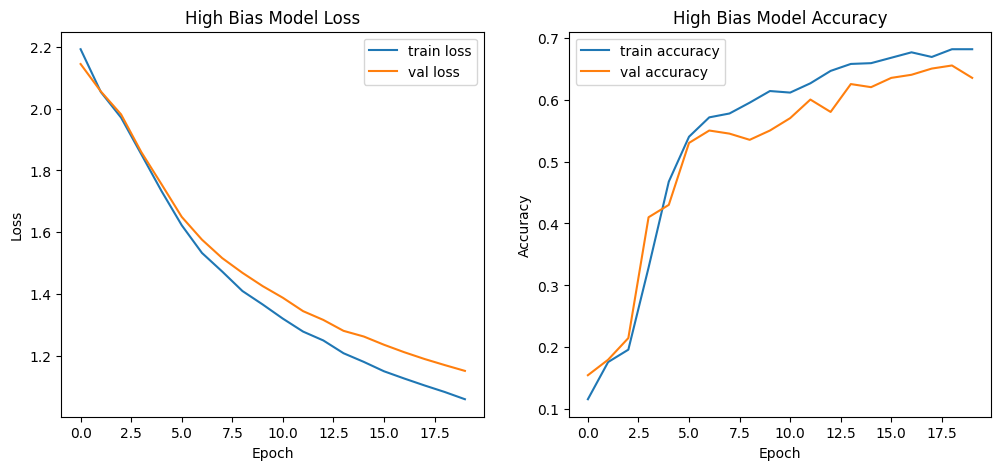

In [16]:
bias_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(4, activation='relu'),
    Dense(10, activation='softmax')
])

bias_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bias_history = bias_model.fit(
    X_small,
    y_small,
    epochs=20,
    validation_split=0.2,
    verbose=False
)

plot_history(bias_history, "High Bias Model")

Loss Came down to 1 for VS and 0.6 for TS

But

Accuraty is 0.65 for Training Set and 0.55 for Validation Set

has high Bias

**Balanced Model :**

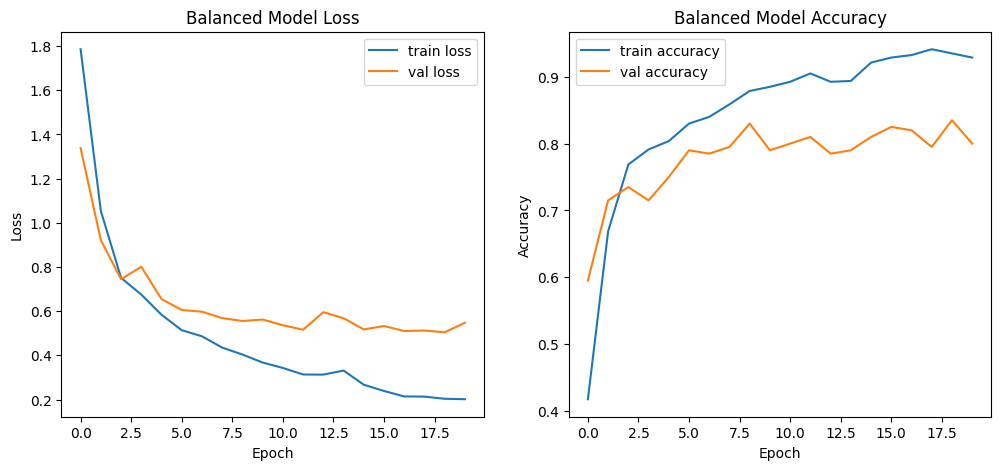

In [17]:
balanced_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(
    X_small,
    y_small,
    epochs=20,
    validation_split=0.2,
    verbose=False
)
plot_history(balanced_history, "Balanced Model")

Training loss came down to 0.1 but Validation loss is about 0.6.

Accuracy comes to 1 for Training set, but for validation set, it's only 0.8

| Situation            | Training Error | Validation Error | Interpretation |
| -------------------- | -------------- | ---------------- | -------------- |
| High Bias            | high           | similar/high     | underfitting   |
| High Variance        | low            | much higher      | overfitting    |
| High Bias + Variance | high           | MUCH higher      | both problems  |


> Validation Loss is wayy Higher than then Training loss, we have a variance here!

Trying a simpler model!

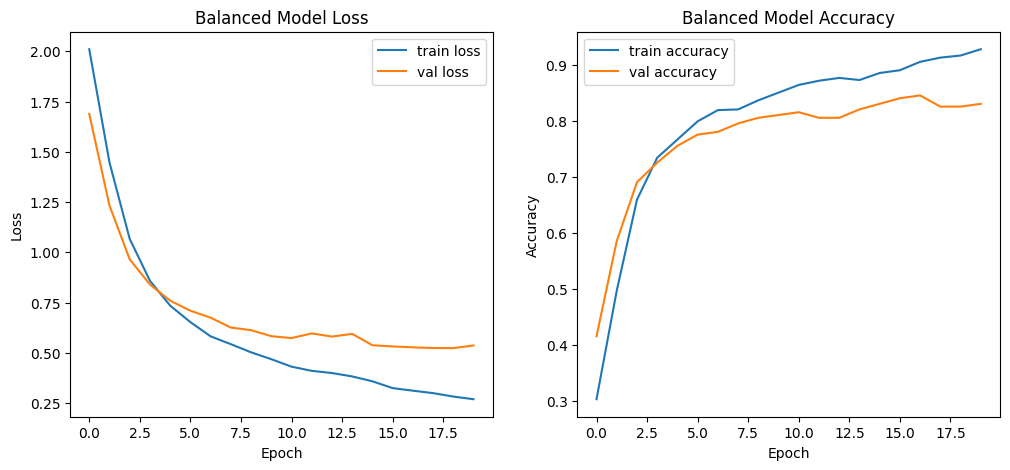

In [18]:
balanced_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(30, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(
    X_small,
    y_small,
    epochs=20,
    validation_split=0.2,
    verbose=False
)
plot_history(balanced_history, "Balanced Model")

loss didn't immprove much, let's try a even simpler model

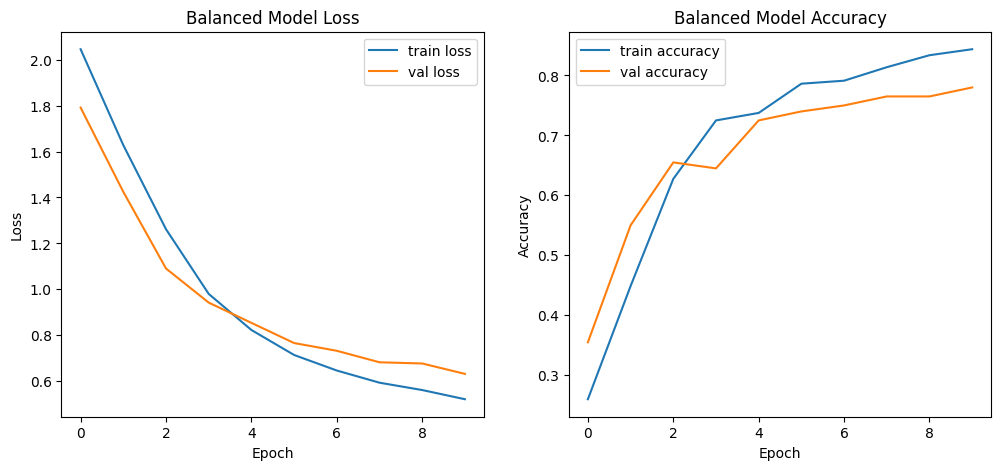

In [19]:
balanced_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(24, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(
    X_small,
    y_small,
    epochs=10,
    validation_split=0.2,
    verbose=False
)
plot_history(balanced_history, "Balanced Model")

Validation and training loss aren't improving much even with simpler model or with less epoch.

It's high variance issue, lets try with
* more data
* smaller set of features
* increase lambda

for this case, getting more data is possible, so lets try that!

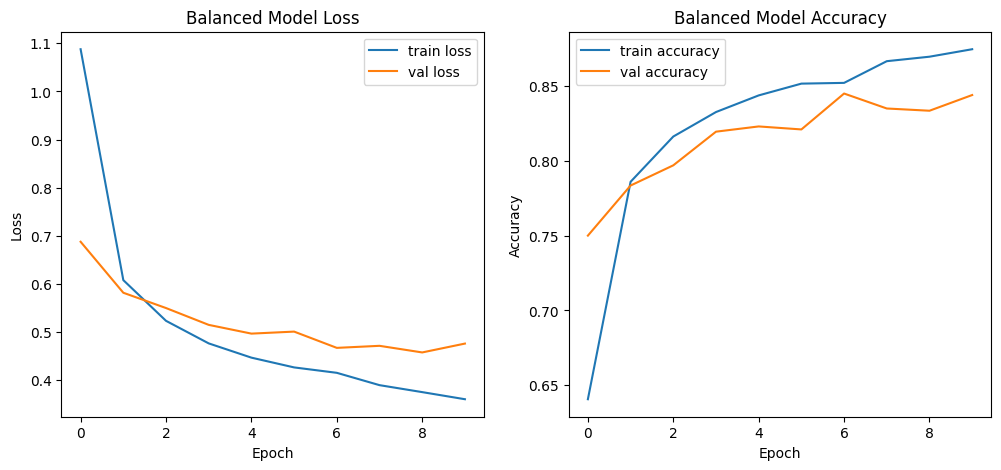

In [20]:
X_mid=X_train[:10000]
y_mid=y_train[:10000]

balanced_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(24, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')
])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(
    X_mid,
    y_mid,
    epochs=10,
    validation_split=0.2,
    verbose=False
)
plot_history(balanced_history, "Balanced Model")



More data reduced variance.


**Before (1000 samples) :**

| Metric              | Result |
| ------------------- | ------ |
| Validation Loss     | ~0.7   |
| Validation Accuracy | ~0.75  |



**Now (10000 samples) :**

| Metric              | Result |
| ------------------- | ------ |
| Validation Loss     | ~0.45  |
| Validation Accuracy | ~0.82  |

That’s a significant improvement.


####  Notice Something VERY Important

We changed:

```text id="jlwmm1"
ONLY the dataset size
```

We did NOT change:

* optimizer
* architecture
* activation
* epochs

That isolates the effect clearly.

This is GOOD experimentation practice.


**What Happened Internally**

With only:

```text id="jlwmm2"
1000 samples
```

the model could:

* partially memorize
* learn unstable patterns
* overfit quickly


With:

```text id="jlwmm3"
10000 samples
```

the model sees:

* more diversity
* more clothing variations
* more examples of each class

So memorization becomes harder.

The network is forced to learn:
**broader/general patterns.**

**THIS Is The Core Variance Insight**

Variance often comes from:

```text id="jlwmm4"
model too dependent on specific training examples
```

More data reduces this dependence.


**Another VERY Important Observation**

Validation accuracy improved:

```text id="jlwmm5"
75% → 82%
```

without increasing model complexity.

This is HUGE.

Because beginners often think:

```text id="jlwmm6"
“better performance = bigger network”
```

But many times:

**better data > bigger model**

This becomes extremely important later in AI/ML.


**Our Validation Loss Also Improved**

```text id="jlwmm7"
0.7 → 0.45
```

Meaning:

* predictions became more confident
* fewer confidently wrong outputs
* generalization improved


For high variance:

* more data
* regularization
* smaller network
* early stopping

We experimentally confirmed:
**more data worked.**

That’s valuable intuition.

**Another Subtle But Important Thing**

We likely still have SOME variance.

Probably:

* train accuracy still higher than validation
* train loss still lower

That’s normal.

Perfectly equal train/validation performance is rare.

The goal is:

``` manageable generalization gap.```

Not:

```text id="jlwmm8"
exact equality
```



### High Variance Model
##

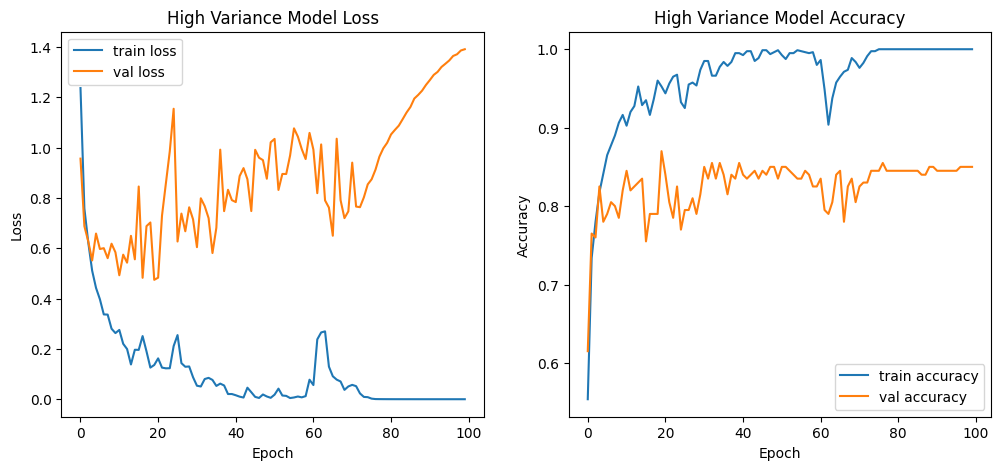

In [21]:
variance_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

variance_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

variance_history = variance_model.fit(
    X_small,
    y_small,
    epochs=100,
    validation_split=0.2,
    verbose=False
)
plot_history(variance_history, "High Variance Model")

Training Loss ~ 0 and Validation Loss Sky Rocketed!

``` High Variance! ```

## Regularization Experiments

> USE THIS WHEN U HAVE HIGH VARIANCE OR OVERFITTING!

Because regularization:

> reduces model complexity/effective memorization.

* Implement Dropout layers.
* Implement L2 regularization.
* Compare performance before and after regularization.
* Observe validation improvements

Regularization means:

> “Prevent the model from becoming overly specialized.”

| Method            | Idea                                     |
| ----------------- | ---------------------------------------- |
| Dropout           | randomly disable neurons during training |
| L2 Regularization | penalize large weights                   |


### Model Comparision:

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import regularizers

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_small = X_train[:1000]
y_small = y_train[:1000]

In [23]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    # ACCURACY
    plt.subplot(1,2,2)

    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')

    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

#### Baseline Model (Model without regularization)

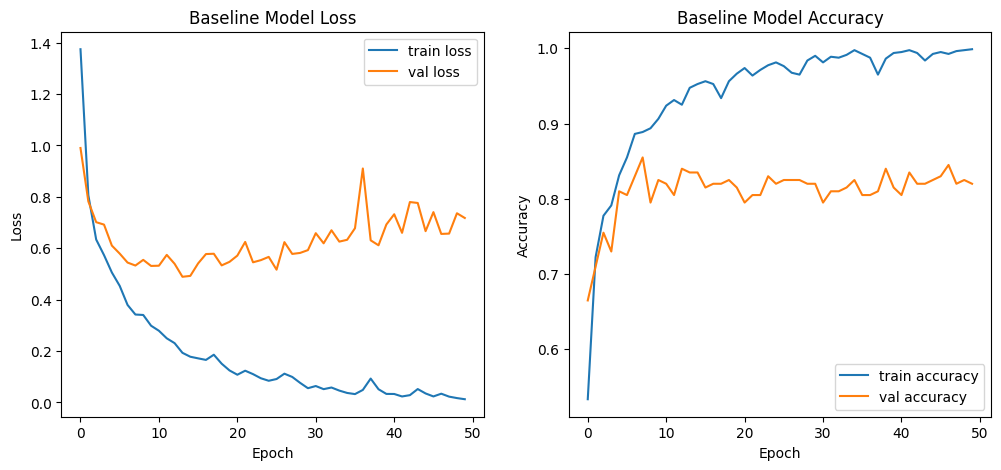

In [24]:
baseline_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    X_small,
    y_small,
    epochs=50,
    validation_split=0.2,
    verbose=False
)
plot_history(baseline_history, "Baseline Model")

For Training Set:

Loss: 1.6 -> 0.01

Accuracy: 0 -> 0.95

For Validation Set:

Loss: 1 -> 0.75

Accuracy: 0.6 -> 0.8

## Dropout Model:



> During training: randomly disables neurons

Example:

dropout = 0.5

means:

> 50% neurons randomly ignored each step.

Prevents:

> neurons becoming overly dependent on each other

Forces:

* more robust learning
* distributed representations
* less memorization

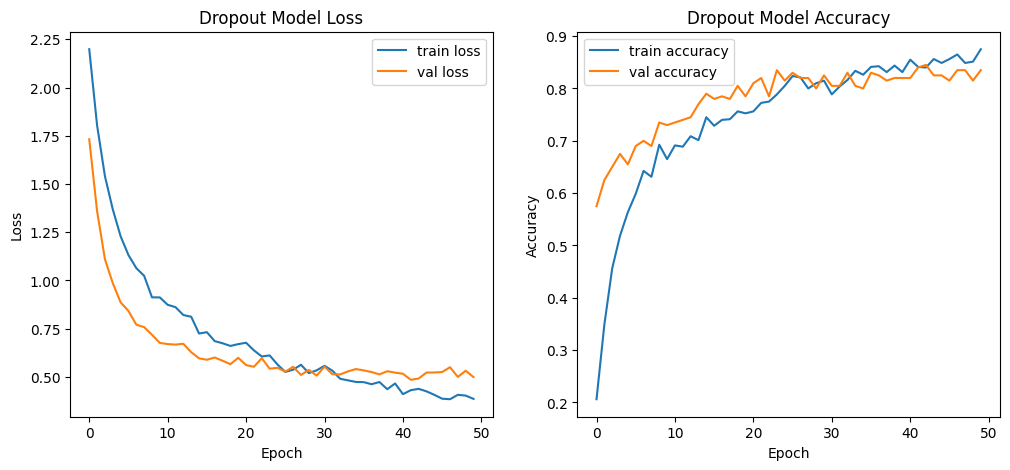

In [25]:
dropout_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dropout_history = dropout_model.fit(
    X_small,
    y_small,
    epochs=50,
    validation_split=0.2,
    verbose=False
)

plot_history(dropout_history, "Dropout Model")

For Training Set:

    Loss: 2.2 -> 0.3

    Accuracy: 0.2 -> 0.9
For Validation Set:

    Loss: 1.5 -> 0.6

    Accuracy: 0.6 -> 0.85

## L2 Regularization:

What L2 Does

Adds penalty term:

``` Loss=Original Loss+λ∑w^2 ```

Meaning:

> large weights become expensive
model prefers smaller/smoother weights

WHY This Helps

Large weights often create:

* sharp decision boundaries
* unstable memorization

L2 encourages:

smoother/generalizable behavior

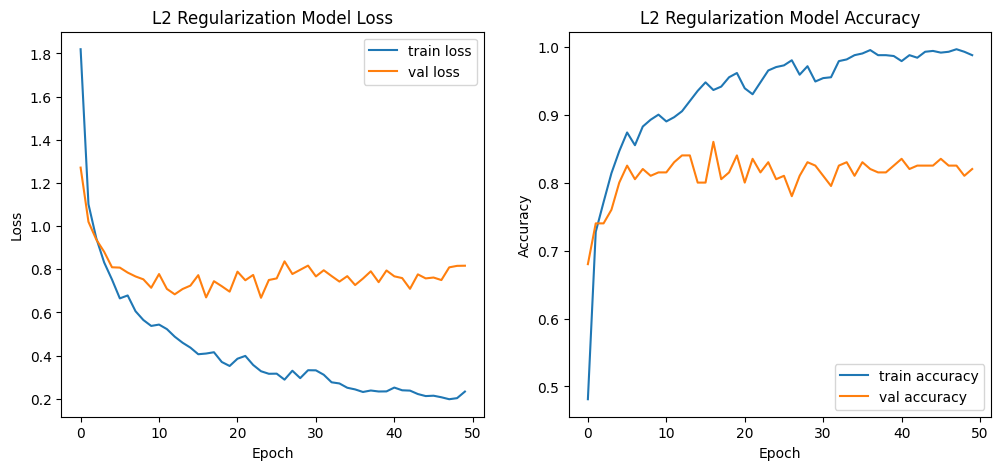

In [26]:
l2_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

l2_history = l2_model.fit(
    X_small,
    y_small,
    epochs=50,
    validation_split=0.2,
    verbose=False
)

plot_history(l2_history, "L2 Regularization Model")

#### Workflow:
1. Train baseline model.

    No heavy regularization initially.

2. Diagnose:

    * bias?
    * variance?
    * data issue?
    * optimization issue?
    
    using:

    * train/validation curves
    * learning curves
    * metrics

3. Apply targeted fix.

    Not random fixes.


#### Practical Intuition About Methods

**Dropout:**

Usually useful when:

    * neural nets large
    * overfitting obvious
    * dataset relatively small

Especially common in:

    * dense layers
    * older CNN architectures
    * L2 Regularization

Usually useful when:

    * weights becoming extreme
    * smoother solutions desired
    * moderate overfitting

Very classical/general technique.

Early Stopping : EXTREMELY common.

```  If validation stops improving: stop training.  ```

Very effective and simple.


**Data Augmentation:**

    Huge in computer vision.

Instead of collecting new data:

* rotate images
* flip images
* crop images
* add noise

Artificially increases diversity.

###  Error Analysis

* Display incorrectly predicted samples.
* Analyze WHY the model failed
* Develop debugging intuition

What Is Error Analysis?

Simple idea:

Instead of only looking at:

    accuracy
    loss
    confusion matrix

we directly inspect:

    the mistakes.

Meaning:

    Which samples did the model predict wrong?

and more importantly:

    WHY did it fail?

Because accuracy alone cannot tell:

    what patterns fail
    which classes confuse the model
    whether data itself is ambiguous
Error analysis reveals:

    model behavior.

Simple Error Analysis Workflow:

1. Predict on test set
2. Find incorrect predictions
3. Display images
4. Compare:
    true label
    predicted label
5. Look for patterns

| Observation               | Possible Meaning           |
| ------------------------- | -------------------------- |
| certain classes confused  | features overlap           |
| blurry images fail        | model sensitive to quality |
| rare styles fail          | insufficient data          |
| unusual orientations fail | lack of augmentation       |


#### Error Ananlysis Process:

#### 1. Prediction:

In [27]:
predictions = balanced_model.predict(X_test)

# predictions contains probability distributions
# Example:
# [0.01, 0.02, 0.7, 0.05, ...]


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step


#### 2. Take the class with highest probability: use argmax

In [29]:
predicted_labels = np.argmax(predictions, axis=1)

In [30]:
predicted_labels

array([9, 2, 1, ..., 8, 1, 5])

#### 3. Find Wrong Predictions

In [31]:
wrong_indices = np.where(predicted_labels != y_test)[0]

print("Total Wrong Predictions:", len(wrong_indices))

Total Wrong Predictions: 1677


#### 4. Display wrong predictions

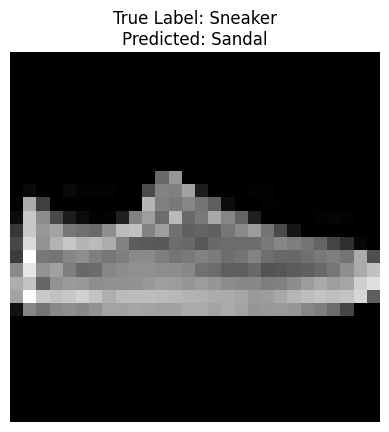

In [32]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

index = wrong_indices[0]
plt.imshow(X_test[index], cmap='gray')
plt.title(
    f"True Label: {class_names[y_test[index]]}\n"
    f"Predicted: {class_names[predicted_labels[index]]}"
)
plt.axis('off')
plt.show()



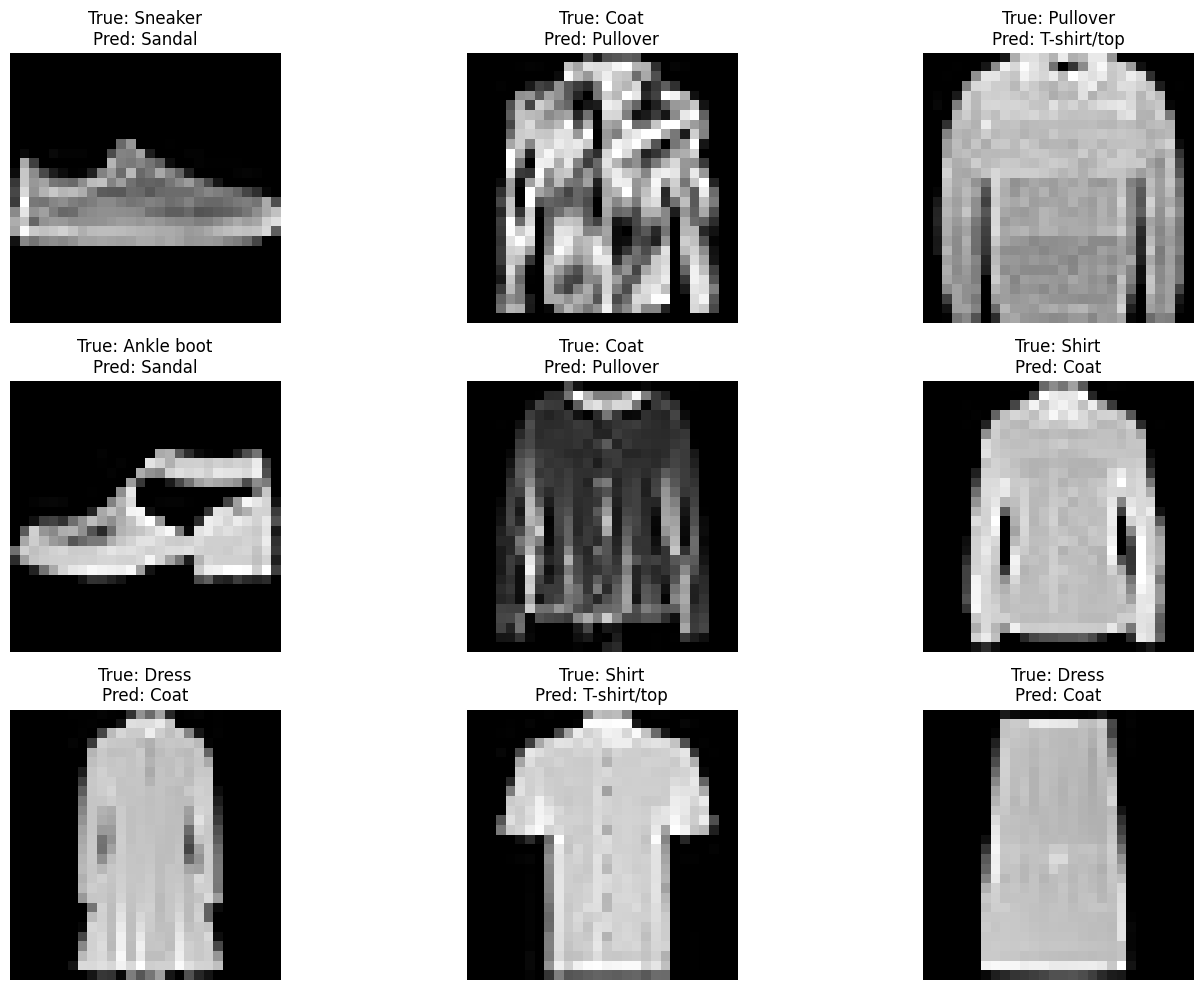

In [34]:
plt.figure(figsize=(15,10))

for i in range(9):
    index = wrong_indices[i]
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[index], cmap='gray')
    plt.title(
        f"True: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[predicted_labels[index]]}"
    )
    plt.axis('off')
plt.tight_layout()

| True Class | Predicted As |
| ---------- | ------------ |
| Pullover   | Shirt        |
| Coat       | Pullover     |
| Shirt      | Coat         |


There are also errors, but these 3 classes are majority!

These classes visually overlap.

    grayscale
    low resolution
    only 28×28

A LOT of fine clothing details disappear.

So:

    sleeves blur together
    collars unclear
    texture lost
    shape simplified

The model is NOT randomly failing.

It is failing : systematically.

Random Failure Would Look Like

| True    | Predicted |
| ------- | --------- |
| Bag     | Sandal    |
| Trouser | Sneaker   |
| Boot    | T-shirt   |

Completely nonsensical.

That would suggest:

    major learning failure
    broken training
    severe bias

> model learned meaningful patterns.

Very important realization.

Real ML Engineers Would Now Think:

| Idea                                 | Why                          |
| ------------------------------------ | ---------------------------- |
| higher resolution images             | preserve details             |
| convolutional neural networks (CNNs) | better spatial understanding |
| more data                            | better variation coverage    |
| data augmentation                    | robustness                   |
| better architecture                  | stronger feature extraction  |


Dense layers flatten images:

    Flatten()

Meaning:

    spatial relationships partially lost
    image structure weakened

And THIS exact problem is why CNNs became revolutionary for vision.